# ECE1508 - Federated Learning Architectures for WiFi-Based Human Activity Recognition

## 1. Setup & Imports

In [1]:
import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


In [2]:
# Task functions
from main.task import (
    CNNModel, ResNet50Model, DenseNetModel,
    load_data, load_centralized_dataset,
    train, test
)

e:\miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading

Train batches: 63, Val batches: 8, Test batches: 8
Images shape: torch.Size([64, 1, 250, 90])
Labels shape: torch.Size([64])
Label values: tensor([0, 1, 2, 3, 4, 5, 6])


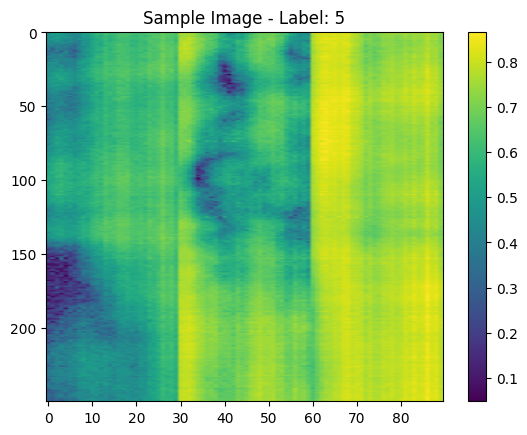

In [3]:
# Load centralized dataset (train + test)
trainloader, valloader, testloader = load_data()
print(f"Train batches: {len(trainloader)}, Val batches: {len(valloader)}, Test batches: {len(testloader)}")

# Check the shapes of the training data
images, labels = next(iter(trainloader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label values:", labels.unique())

# Visualize a sample from the dataset
sample_image, sample_label = images[0], labels[0]
plt.imshow(sample_image.squeeze(), aspect='auto', cmap='viridis')
plt.title(f"Sample Image - Label: {sample_label.item()}")
plt.colorbar()
plt.show()

## 3. Centralized Training

In [5]:
import random
random.seed(42)

lr_options = [0.001, 0.005, 0.01, 0.05]
batch_size_options = [32, 64, 128]
epoch_options = [5, 10, 15]

best_acc = 0
best_config = None
for trial in range(5):
    lr = random.choice(lr_options)
    batch_size = random.choice(batch_size_options)
    epochs = random.choice(epoch_options)
    
    print(f"\nTrial {trial+1}: lr={lr}, batch_size={batch_size}, epochs={epochs}")
    
    trainloader, valloader, testloader = load_data(batch_size=batch_size)
    cnn_model = CNNModel(num_classes=7).to(DEVICE)
    
    train(cnn_model, trainloader, DEVICE, epochs=epochs, lr=lr)
    _, val_acc = test(cnn_model, valloader, DEVICE)
    print(f"Validation Accuracy: {val_acc:.4f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        best_config = {"lr": lr, "batch_size": batch_size, "epochs": epochs}

print(f"\nBest config: {best_config}, Validation Accuracy: {best_acc:.4f}")



Trial 1: lr=0.001, batch_size=32, epochs=15
Starting training...
Epoch 1/15, Loss: 2.6755, Accuracy: 0.5466
Epoch 2/15, Loss: 0.6643, Accuracy: 0.7621
Epoch 3/15, Loss: 0.3377, Accuracy: 0.8836
Epoch 4/15, Loss: 0.2417, Accuracy: 0.9173
Epoch 5/15, Loss: 0.2402, Accuracy: 0.9228
Epoch 6/15, Loss: 0.2046, Accuracy: 0.9291
Epoch 7/15, Loss: 0.1072, Accuracy: 0.9638
Epoch 8/15, Loss: 0.0869, Accuracy: 0.9686
Epoch 9/15, Loss: 0.0834, Accuracy: 0.9726
Epoch 10/15, Loss: 0.0688, Accuracy: 0.9769
Epoch 11/15, Loss: 0.0894, Accuracy: 0.9711
Epoch 12/15, Loss: 0.0575, Accuracy: 0.9819
Epoch 13/15, Loss: 0.0277, Accuracy: 0.9909
Epoch 14/15, Loss: 0.0187, Accuracy: 0.9937
Epoch 15/15, Loss: 0.0275, Accuracy: 0.9909
Validation Accuracy: 0.9758

Trial 2: lr=0.01, batch_size=32, epochs=5
Starting training...
Epoch 1/5, Loss: 12.6706, Accuracy: 0.2610
Epoch 2/5, Loss: 1.7929, Accuracy: 0.2952
Epoch 3/5, Loss: 1.7561, Accuracy: 0.2944
Epoch 4/5, Loss: 1.7421, Accuracy: 0.2967
Epoch 5/5, Loss: 1.722

In [7]:
trainloader, valloader, testloader = load_data(batch_size=64)
cnn_model = CNNModel(num_classes=7).to(DEVICE)
cnn_train_loss = train(
    net=cnn_model,
    trainloader=trainloader,
    epochs=5,
    lr=0.001,
    device=DEVICE
)

cnn_test_loss, cnn_test_acc = test(
    net=cnn_model,
    testloader=testloader,
    device=DEVICE
)
print(f"Test loss: {cnn_test_loss:.4f}, Test accuracy: {cnn_test_acc*100:.2f}%")

Starting training...
Epoch 1/5, Loss: 3.3755, Accuracy: 0.5004
Epoch 2/5, Loss: 0.6210, Accuracy: 0.7898
Epoch 3/5, Loss: 0.4273, Accuracy: 0.8542
Epoch 4/5, Loss: 0.3393, Accuracy: 0.8765
Epoch 5/5, Loss: 0.1991, Accuracy: 0.9253
Test loss: 0.2725, Test accuracy: 91.00%


In [ ]:
res_net50_model = ResNet50Model(num_classes=7).to(DEVICE)
res_train_loss_resnet = train(
    net=res_net50_model,
    trainloader=trainloader,
    epochs=5,
    lr=0.001,
    device=DEVICE
)

res_test_loss_resnet, res_test_acc_resnet = test(
    net=res_net50_model,
    testloader=testloader,
    device=DEVICE
)
print(f"ResNet50 - Test loss: {res_test_loss_resnet:.4f}, Test accuracy: {res_test_acc_resnet*100:.2f}%")

Starting training...


In [ ]:
dense_net_model = DenseNetModel(num_classes=7).to(DEVICE)
dense_train_loss_densenet = train(
    net=dense_net_model,
    trainloader=trainloader,
    epochs=5,
    lr=0.01,
    device=DEVICE
)

dense_test_loss, dense_test_acc = test(
    net=dense_net_model,
    testloader=testloader,
    device=DEVICE
)
print(f"Test loss: {dense_test_loss:.4f}, Test accuracy: {dense_test_acc*100:.2f}%")

## 4. Federated Learning (Decentralized)